# VK-LSVD: чувствительность рекомендаций к коллаборативным и контентным сигналам

**Задача.** Реализовать несколько алгоритмов коллаборативной фильтрации, добавить контентные эмбеддинги и оценить их влияние на точность, устойчивость и качество ранжирования на датасете [deepvk/VK-LSVD](https://huggingface.co/datasets/deepvk/VK-LSVD).

**Переформулировка модальностей.** В VK-LSVD один унифицированный контентный эмбеддинг айтема (видео+описание+аудио), а не раздельные текст/изображение, и нет сырых заголовков/кадров. Поэтому сравнение «текст vs изображение vs мультимодальность» заменено на нативное свойство датасета: компоненты эмбеддинга упорядочены, и dot первых *n* компонент ≈ косинусу полного вектора — размерность (8/16/32/64) выступает как управляемая «сила контентного сигнала».

**Пайплайн:** данные → разметка вовлечённости → CF-модели (ALS, ItemKNN, UserKNN) → контентное позднее слияние (α-сетка + развёртка по размерности) → cold-start → бутстрап-значимость → фигуры и таблицы.

## 0. Зависимости и данные

Ячейка ниже опциональна: если пяти файлов подвыборки нет рядом с ноутбуком, она скачает их напрямую через `curl` (в обход капризного HEAD-эндпоинта HF) и соберёт компактный бандл `vk_lsvd_mini`. Если файлы уже загружены — шаг пропускается.

In [1]:
import importlib.util, subprocess, sys
need = [p for p in ("implicit","polars","scipy","sklearn","matplotlib","numpy") if importlib.util.find_spec(p) is None]
if need:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "implicit>=0.7", "polars>=1.0", "scipy>=1.11",
                           "scikit-learn>=1.3", "matplotlib>=3.7", "numpy>=1.24"])
print("Зависимости готовы.")

Зависимости готовы.


In [2]:
import os, shutil, subprocess, numpy as np, polars as pl

BUNDLE = ["train.parquet", "val.parquet", "items_metadata.parquet",
          "users_metadata.parquet", "item_embeddings.npz"]

if all(os.path.exists(f) for f in BUNDLE):
    print("Бандл найден рядом с ноутбуком — пропускаем загрузку.")
elif os.path.isdir("vk_lsvd_mini") and all(os.path.exists(f"vk_lsvd_mini/{f}") for f in BUNDLE):
    for f in BUNDLE: shutil.copy(f"vk_lsvd_mini/{f}", f)
    print("Бандл скопирован из vk_lsvd_mini/.")
else:
    REPO, SUBSAMPLE, N_TRAIN_WEEKS = "deepvk/VK-LSVD", "up0.001_ip0.001", 25
    N_USERS, MAX_INT_PER_USER, EMB_DIM = 1500, 400, 64
    BASE = f"https://huggingface.co/datasets/{REPO}/resolve/main"
    def fetch(rel):
        out = f"VK-LSVD/{rel}"; os.makedirs(os.path.dirname(out), exist_ok=True)
        if os.path.exists(out) and os.path.getsize(out) > 0: return out
        subprocess.run(["curl","-L","--fail","--retry","20","--retry-delay","5",
                        "--retry-all-errors","-C","-","-o",out,f"{BASE}/{rel}?download=true"],
                       check=True)
        return out
    tf = [f"subsamples/{SUBSAMPLE}/train/week_{i:02}.parquet" for i in range(N_TRAIN_WEEKS)]
    vf = f"subsamples/{SUBSAMPLE}/validation/week_{N_TRAIN_WEEKS:02}.parquet"
    mf = ["metadata/users_metadata.parquet","metadata/items_metadata.parquet","metadata/item_embeddings.npz"]
    for f in tf + [vf] + mf: fetch(f)
    tr = pl.concat([pl.scan_parquet(f"VK-LSVD/{f}") for f in tf]).collect(engine="streaming")
    va = pl.read_parquet(f"VK-LSVD/{vf}")
    ku = tr.select("user_id").unique().sort("user_id").head(N_USERS)
    tr, va = tr.join(ku, on="user_id"), va.join(ku, on="user_id")
    tr = (tr.with_columns(pl.int_range(pl.len()).over("user_id").alias("i"),
                          pl.len().over("user_id").alias("c"))
            .filter(pl.col("i") >= pl.col("c") - MAX_INT_PER_USER).drop(["i","c"]))
    ki = tr.select("item_id").unique()
    e = np.load("VK-LSVD/metadata/item_embeddings.npz"); ids, em = e["item_id"], e["embedding"]
    m = np.isin(ids, ki.to_numpy().ravel()); ids, em = ids[m], em[m][:, :EMB_DIM]
    tr.write_parquet("train.parquet", compression="zstd")
    va.write_parquet("val.parquet", compression="zstd")
    pl.read_parquet("VK-LSVD/metadata/items_metadata.parquet").join(ki, on="item_id").write_parquet("items_metadata.parquet", compression="zstd")
    pl.read_parquet("VK-LSVD/metadata/users_metadata.parquet").join(ku, on="user_id").write_parquet("users_metadata.parquet", compression="zstd")
    np.savez_compressed("item_embeddings.npz", item_id=ids, embedding=em)
    print("Бандл собран.")
for f in BUNDLE:
    print(f, round(os.path.getsize(f)/1e6, 2), "MB" if os.path.exists(f) else "ОТСУТСТВУЕТ")

Бандл собран.
train.parquet 2.75 MB
val.parquet 0.38 MB
items_metadata.parquet 0.11 MB
users_metadata.parquet 0.01 MB
item_embeddings.npz 1.41 MB


In [3]:
import os, json, numpy as np, polars as pl, scipy.sparse as sp
import matplotlib.pyplot as plt
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import CosineRecommender

RNG = np.random.default_rng(0)
OUT = "outputs"; os.makedirs(OUT, exist_ok=True)
K = 10; DIMS = [8,16,32,64]; ALPHAS = [0.1,0.5,1.0]
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Фаза 1. Загрузка и разметка вовлечённости

Явные реакции в коротком видео редки (~1% лайков), поэтому положительный класс = лайк ∨ репост ∨ сохранение ∨ переход к автору ∨ досмотр ≥ 70% длительности.

In [4]:
def engaged():
    dur = pl.when(pl.col("duration")==0).then(1).otherwise(pl.col("duration"))
    return (pl.col("like")|pl.col("share")|pl.col("bookmark")|pl.col("click_on_author")
            |(pl.col("timespent")/dur >= 0.7))

im = pl.read_parquet("items_metadata.parquet")
tr = pl.read_parquet("train.parquet").join(im.select(["item_id","duration"]), on="item_id", how="left").with_columns(engaged().alias("eng"))
va = pl.read_parquet("val.parquet").join(im.select(["item_id","duration"]), on="item_id", how="left").with_columns(engaged().alias("eng"))
emb = np.load("item_embeddings.npz")
sparsity = 1 - tr.filter(pl.col("eng")).height / (tr["user_id"].n_unique()*im.height)
print(f"users={tr['user_id'].n_unique()} items={im.height} pos_train={tr['eng'].sum()} val_users={va['user_id'].n_unique()}")
print(f"разреженность положительной матрицы: {sparsity:.4%}")

users=1500 items=11522 pos_train=152660 val_users=1487
разреженность положительной матрицы: 99.1167%


## Фаза 1b. Индексы, разреженные матрицы, эмбеддинги

In [5]:
users = tr["user_id"].unique().sort().to_list(); items = im["item_id"].unique().sort().to_list()
uix = {u:i for i,u in enumerate(users)}; iix = {v:i for i,v in enumerate(items)}
nU, nI = len(users), len(items)

trp = tr.filter(pl.col("eng"))
ru = np.array([uix[u] for u in trp["user_id"]]); ri = np.array([iix[v] for v in trp["item_id"]])
R = sp.csr_matrix((np.ones(len(ru),np.float32),(ru,ri)), shape=(nU,nI)); R.sum_duplicates(); R.data[:] = 1.0

vp = va.filter(pl.col("eng")).filter(pl.col("item_id").is_in(items)); val_pos = {}
for u,v in zip(vp["user_id"].to_list(), vp["item_id"].to_list()): val_pos.setdefault(uix[u],set()).add(iix[v])
val_users = np.array(sorted(val_pos))

eid = {int(x):k for k,x in enumerate(emb["item_id"])}; E = np.zeros((nI, emb["embedding"].shape[1]), np.float32)
for v,j in iix.items(): E[j] = emb["embedding"][eid[v]]

vu = val_users.copy(); RNG.shuffle(vu); c = int(0.3*len(vu)); tune_u = set(vu[:c].tolist())
tune_mask = np.array([u in tune_u for u in val_users]); test_mask = ~tune_mask
print("матрица R:", R.shape, "nnz", R.nnz, "| test", test_mask.sum(), "tune", tune_mask.sum())

матрица R: (1500, 11522) nnz 152660 | test 1018 tune 435


## Фаза 2. Коллаборативные модели и метрики

Протокол — полное ранжирование по всему каталогу с исключением уже виденных айтемов. Метрики: HitRate@1, HitRate@10, NDCG@10, Coverage@10. Функции возвращают per-user массивы, чтобы затем считать бутстрап.

In [6]:
def als_scores(factors=64, reg=0.05, iters=25, mat=None):
    m = AlternatingLeastSquares(factors=factors, regularization=reg, iterations=iters, random_state=0, use_gpu=False)
    m.fit(R if mat is None else mat, show_progress=False)
    return m, (m.user_factors[val_users] @ m.item_factors.T).astype(np.float32)

def itemknn_scores(k=200):
    m = CosineRecommender(K=k); m.fit(R, show_progress=False)
    return np.asarray((R[val_users] @ m.similarity).todense(), np.float32)

def userknn_scores(k=100):
    nrm = np.sqrt(np.asarray(R.multiply(R).sum(1)).ravel()); nrm[nrm==0]=1
    Rn = R.multiply(1/nrm[:,None]).tocsr(); sim = (Rn[val_users] @ Rn.T).toarray()
    for r,u in enumerate(val_users): sim[r,u]=0.0
    cut = np.partition(sim,-k,axis=1)[:,-k][:,None]; sim[sim<cut]=0
    return (sim @ R).astype(np.float32)

def per_user_metrics(S):
    S = S.copy(); seen = R[val_users].tolil().rows
    for r,cols in enumerate(seen):
        if cols: S[r,cols] = -np.inf
    order = np.argsort(-S,axis=1)[:,:K]; hit1=[];hit10=[];ndcg=[];top=set()
    for r in range(len(val_users)):
        pos = val_pos[val_users[r]]; rank=order[r]; top.update(rank.tolist())
        h=[1 if j in pos else 0 for j in rank]; hit1.append(h[0]); hit10.append(1 if sum(h) else 0)
        idcg=sum(1/np.log2(i+2) for i in range(min(len(pos),K)))
        ndcg.append(sum(h[i]/np.log2(i+2) for i in range(K))/idcg if idcg else 0.0)
    return dict(hit1=np.array(hit1),hit10=np.array(hit10),ndcg=np.array(ndcg),coverage=len(top)/nI)

def agg(m, mask=test_mask):
    return dict(HitRate_1=float(np.nanmean(m["hit1"][mask])), HitRate_10=float(np.nanmean(m["hit10"][mask])),
                NDCG_10=float(np.nanmean(m["ndcg"][mask])), Coverage_10=float(m["coverage"]))

als_model, S_als = als_scores(); S_ik = itemknn_scores(); S_uk = userknn_scores()
for nm,S in [("ALS",S_als),("ItemKNN",S_ik),("UserKNN",S_uk)]:
    print(f"{nm:8s}", {k:round(v,4) for k,v in agg(per_user_metrics(S)).items()})

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0012729167938232422 seconds
  warnings.warn(


ALS      {'HitRate_1': 0.0069, 'HitRate_10': 0.0815, 'NDCG_10': 0.0092, 'Coverage_10': 0.0425}
ItemKNN  {'HitRate_1': 0.0029, 'HitRate_10': 0.0747, 'NDCG_10': 0.0082, 'Coverage_10': 0.0175}
UserKNN  {'HitRate_1': 0.0059, 'HitRate_10': 0.0766, 'NDCG_10': 0.0086, 'Coverage_10': 0.016}


Визуализация распределения предсказанных скоров ALS.

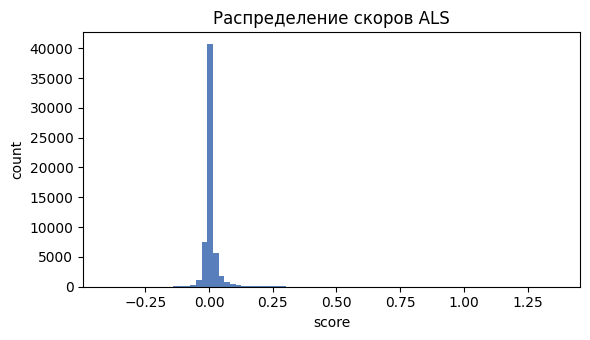

In [7]:
v = S_als[test_mask].ravel(); v = v[np.isfinite(v)]
plt.figure(figsize=(6,3.5)); plt.hist(v[RNG.integers(0,len(v),60000)], bins=80, color="#2E5EAA", alpha=.8)
plt.title("Распределение скоров ALS"); plt.xlabel("score"); plt.ylabel("count"); plt.tight_layout(); plt.show()

## Фаза 3. Контент и позднее слияние

Профиль пользователя — среднее эмбеддингов вовлечённых айтемов. Скор слияния: `z(ALS) + α·z(Content)` (построчная стандартизация). Подбираем α по сетке и размерность d по {8,16,32,64}.

In [8]:
def content_scores(dim):
    Ed = E[:,:dim]; prof = R[val_users] @ Ed
    cnt = np.asarray(R[val_users].sum(1)).ravel(); cnt[cnt==0]=1
    return ((prof/cnt[:,None]) @ Ed.T).astype(np.float32)

def zrows(S):
    mu=S.mean(1,keepdims=True); sd=S.std(1,keepdims=True); sd[sd==0]=1; return (S-mu)/sd
def fuse(cf, content, alpha): return zrows(cf) + alpha*zrows(content)

grid = []
for a in ALPHAS:
    mt = per_user_metrics(fuse(S_als, content_scores(64), a))
    grid.append(dict(alpha=a, tune_NDCG=agg(mt,tune_mask)["NDCG_10"], test_NDCG=agg(mt,test_mask)["NDCG_10"]))
best_alpha = max(grid, key=lambda r:r["tune_NDCG"])["alpha"]
print(pl.DataFrame(grid)); print("best_alpha =", best_alpha)

shape: (3, 3)
┌───────┬───────────┬───────────┐
│ alpha ┆ tune_NDCG ┆ test_NDCG │
│ ---   ┆ ---       ┆ ---       │
│ f64   ┆ f64       ┆ f64       │
╞═══════╪═══════════╪═══════════╡
│ 0.1   ┆ 0.012788  ┆ 0.0093    │
│ 0.5   ┆ 0.013325  ┆ 0.009264  │
│ 1.0   ┆ 0.012698  ┆ 0.009358  │
└───────┴───────────┴───────────┘
best_alpha = 0.5


shape: (4, 5)
┌─────┬───────────┬────────────┬──────────┬─────────────┐
│ dim ┆ HitRate_1 ┆ HitRate_10 ┆ NDCG_10  ┆ Coverage_10 │
│ --- ┆ ---       ┆ ---        ┆ ---      ┆ ---         │
│ i64 ┆ f64       ┆ f64        ┆ f64      ┆ f64         │
╞═════╪═══════════╪════════════╪══════════╪═════════════╡
│ 8   ┆ 0.007859  ┆ 0.079568   ┆ 0.009407 ┆ 0.042961    │
│ 16  ┆ 0.007859  ┆ 0.079568   ┆ 0.009352 ┆ 0.042961    │
│ 32  ┆ 0.007859  ┆ 0.078585   ┆ 0.009299 ┆ 0.043222    │
│ 64  ┆ 0.006876  ┆ 0.079568   ┆ 0.009264 ┆ 0.043048    │
└─────┴───────────┴────────────┴──────────┴─────────────┘
best_dim = 8


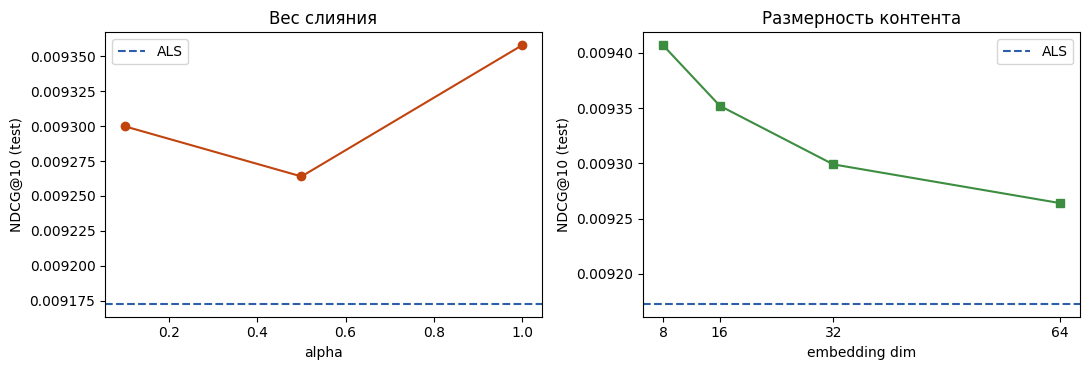

In [9]:
sweep = []; cc = {}
for dmn in DIMS:
    cc[dmn] = content_scores(dmn); a_ = agg(per_user_metrics(fuse(S_als, cc[dmn], best_alpha))); a_["dim"]=dmn; sweep.append(a_)
best_dim = max(sweep, key=lambda r:r["NDCG_10"])["dim"]
print(pl.DataFrame(sweep).select(["dim","HitRate_1","HitRate_10","NDCG_10","Coverage_10"])); print("best_dim =", best_dim)

als_ndcg = agg(per_user_metrics(S_als))["NDCG_10"]
fig,ax = plt.subplots(1,2,figsize=(11,3.8))
ax[0].plot([r["alpha"] for r in grid],[r["test_NDCG"] for r in grid],"o-",color="#C1440E"); ax[0].axhline(als_ndcg,ls="--",color="#2E5EAA",label="ALS")
ax[0].set_xlabel("alpha"); ax[0].set_ylabel("NDCG@10 (test)"); ax[0].set_title("Вес слияния"); ax[0].legend()
ax[1].plot([r["dim"] for r in sweep],[r["NDCG_10"] for r in sweep],"s-",color="#3C8D40"); ax[1].axhline(als_ndcg,ls="--",color="#2E5EAA",label="ALS")
ax[1].set_xlabel("embedding dim"); ax[1].set_ylabel("NDCG@10 (test)"); ax[1].set_xticks(DIMS); ax[1].set_title("Размерность контента"); ax[1].legend()
plt.tight_layout(); plt.show()

## Фаза 4. Четыре сценария и сводная таблица

1) Чистый CF (ALS) · 2) ItemKNN · 3) UserKNN · 4) Content-Boosted CF (ALS+Content) — плюс Content-only как референс.

In [10]:
S_fuse = fuse(S_als, cc[best_dim], best_alpha); S_con = content_scores(best_dim)
fuse_name = f"ALS+Content (a={best_alpha}, d={best_dim})"
models = {"ALS (CF only)":S_als, "ItemKNN":S_ik, "UserKNN":S_uk, "Content only":S_con, fuse_name:S_fuse}
peruser = {nm: per_user_metrics(S) for nm,S in models.items()}
main = [{"model":nm, **{k:round(v,5) for k,v in agg(peruser[nm]).items()}} for nm in models]
main_df = pl.DataFrame(main); print(main_df)

shape: (5, 5)
┌──────────────────────────┬───────────┬────────────┬─────────┬─────────────┐
│ model                    ┆ HitRate_1 ┆ HitRate_10 ┆ NDCG_10 ┆ Coverage_10 │
│ ---                      ┆ ---       ┆ ---        ┆ ---     ┆ ---         │
│ str                      ┆ f64       ┆ f64        ┆ f64     ┆ f64         │
╞══════════════════════════╪═══════════╪════════════╪═════════╪═════════════╡
│ ALS (CF only)            ┆ 0.00688   ┆ 0.08153    ┆ 0.00917 ┆ 0.04253     │
│ ItemKNN                  ┆ 0.00295   ┆ 0.07466    ┆ 0.00821 ┆ 0.01753     │
│ UserKNN                  ┆ 0.00589   ┆ 0.07662    ┆ 0.00856 ┆ 0.01597     │
│ Content only             ┆ 0.00098   ┆ 0.01277    ┆ 0.00153 ┆ 0.0151      │
│ ALS+Content (a=0.5, d=8) ┆ 0.00786   ┆ 0.07957    ┆ 0.00941 ┆ 0.04296     │
└──────────────────────────┴───────────┴────────────┴─────────┴─────────────┘


Radar-сравнение четырёх моделей (значения нормированы на максимум по оси).

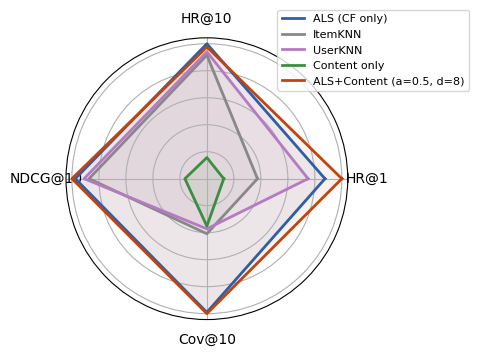

In [11]:
axes=["HitRate_1","HitRate_10","NDCG_10","Coverage_10"]; labels=["HR@1","HR@10","NDCG@10","Cov@10"]
ang=np.linspace(0,2*np.pi,len(axes),endpoint=False).tolist(); ang+=ang[:1]
mx={k:max(agg(peruser[nm])[k] for nm in models) for k in axes}
fig,ax=plt.subplots(figsize=(5.5,5.5),subplot_kw=dict(polar=True))
cols=["#2E5EAA","#888888","#B47AC2","#3C8D40","#C1440E"]
for nm,col in zip(models,cols):
    a_=agg(peruser[nm]); nrm=[a_[axes[i]]/mx[axes[i]] if mx[axes[i]] else 0 for i in range(len(axes))]; nrm+=nrm[:1]
    ax.plot(ang,nrm,"-",lw=2,label=nm,color=col); ax.fill(ang,nrm,alpha=.07,color=col)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels); ax.set_yticklabels([])
ax.legend(loc="upper right", bbox_to_anchor=(1.45,1.12), fontsize=8); plt.tight_layout(); plt.show()

## Фаза 5. Cold-start и статистическая значимость

**Cold-start:** случайно прячем 15% айтемов из обучения ALS (их факторы неинформативны) и ранжируем внутри «холодного» пула. Контент использует эмбеддинги, доступные для всех айтемов.

In [12]:
RC = np.random.default_rng(7); cold_hold = np.sort(RC.choice(nI, int(0.15*nI), replace=False))
cold_set = set(cold_hold.tolist()); Rw = R.tolil(); Rw[:,cold_hold]=0; Rw=Rw.tocsr(); Rw.eliminate_zeros()
mc,_ = als_scores(mat=Rw)
als_c = (mc.user_factors[val_users] @ mc.item_factors[cold_hold].T).astype(np.float32)
Ec = E[cold_hold,:best_dim]; prof = R[val_users] @ E[:,:best_dim]; cnt=np.asarray(R[val_users].sum(1)).ravel(); cnt[cnt==0]=1
con_c = ((prof/cnt[:,None]) @ Ec.T).astype(np.float32); fus_c = zrows(als_c)+best_alpha*zrows(con_c)
cix = {c:k for k,c in enumerate(cold_hold)}; seen = R[val_users].tolil().rows
def cold_eval(S):
    hr=[];nd=[];used=[]
    for r in range(len(val_users)):
        posc=[cix[j] for j in (val_pos[val_users[r]] & cold_set)]
        if not posc: continue
        s=S[r].copy()
        for j in seen[r]:
            if j in cix: s[cix[j]]=-np.inf
        order=np.argsort(-s)[:K]; h=[1 if j in posc else 0 for j in order]
        idcg=sum(1/np.log2(i+2) for i in range(min(len(posc),K)))
        hr.append(1 if sum(h) else 0); nd.append(sum(h[i]/np.log2(i+2) for i in range(K))/idcg); used.append(r)
    used=np.array(used); m=test_mask[used]
    return float(np.array(hr)[m].mean()), float(np.array(nd)[m].mean()), int(m.sum())
cold=[]
for nm,S in [("ALS (CF only)",als_c),("Content only",con_c),("ALS+Content",fus_c)]:
    hr,nd,n=cold_eval(S); cold.append({"model":nm,"HitRate_10":round(hr,5),"NDCG_10":round(nd,5),"n_users":n})
cold_df = pl.DataFrame(cold); print(cold_df)

shape: (3, 4)
┌───────────────┬────────────┬─────────┬─────────┐
│ model         ┆ HitRate_10 ┆ NDCG_10 ┆ n_users │
│ ---           ┆ ---        ┆ ---     ┆ ---     │
│ str           ┆ f64        ┆ f64     ┆ i64     │
╞═══════════════╪════════════╪═════════╪═════════╡
│ ALS (CF only) ┆ 0.01567    ┆ 0.00505 ┆ 702     │
│ Content only  ┆ 0.03276    ┆ 0.01025 ┆ 702     │
│ ALS+Content   ┆ 0.03276    ┆ 0.01025 ┆ 702     │
└───────────────┴────────────┴─────────┴─────────┘


shape: (4, 6)
┌─────────────────────────────────┬────────────┬──────────┬──────────┬─────────┬─────────────┐
│ comparison                      ┆ delta_NDCG ┆ ci_lo    ┆ ci_hi    ┆ p_value ┆ significant │
│ ---                             ┆ ---        ┆ ---      ┆ ---      ┆ ---     ┆ ---         │
│ str                             ┆ f64        ┆ f64      ┆ f64      ┆ f64     ┆ bool        │
╞═════════════════════════════════╪════════════╪══════════╪══════════╪═════════╪═════════════╡
│ ItemKNN vs ALS                  ┆ -0.00096   ┆ -0.00386 ┆ 0.00219  ┆ 0.524   ┆ false       │
│ UserKNN vs ALS                  ┆ -0.00062   ┆ -0.00316 ┆ 0.00197  ┆ 0.654   ┆ false       │
│ Content only vs ALS             ┆ -0.00764   ┆ -0.00999 ┆ -0.00564 ┆ 0.0     ┆ true        │
│ ALS+Content (a=0.5, d=8) vs AL… ┆ 0.00023    ┆ -0.0006  ┆ 0.00117  ┆ 0.586   ┆ false       │
└─────────────────────────────────┴────────────┴──────────┴──────────┴─────────┴─────────────┘


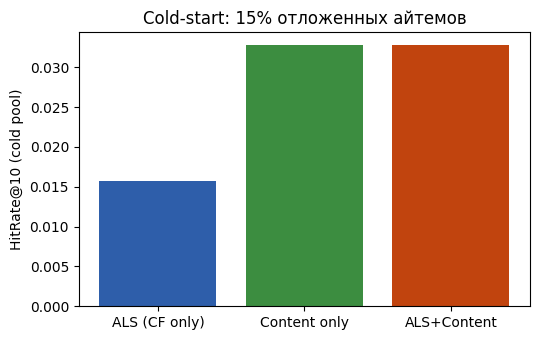

In [13]:
def bootstrap_diff(a,b,mask,B=1000):
    a=a[mask]; b=b[mask]; n=len(a); idx=RNG.integers(0,n,(B,n)); dif=b[idx].mean(1)-a[idx].mean(1)
    lo,hi=np.percentile(dif,[2.5,97.5]); p=2*min((dif<=0).mean(),(dif>=0).mean())
    return float(b.mean()-a.mean()),float(lo),float(hi),float(min(p,1.0))
base=peruser["ALS (CF only)"]["ndcg"]; boot=[]
for nm in ["ItemKNN","UserKNN","Content only",fuse_name]:
    dd,lo,hi,p=bootstrap_diff(base,peruser[nm]["ndcg"],test_mask)
    boot.append(dict(comparison=f"{nm} vs ALS",delta_NDCG=round(dd,5),ci_lo=round(lo,5),ci_hi=round(hi,5),p_value=round(p,4),significant=bool(p<0.05)))
boot_df=pl.DataFrame(boot); print(boot_df)

plt.figure(figsize=(5.5,3.5)); nm=[r["model"] for r in cold]
plt.bar(nm,[r["HitRate_10"] for r in cold],color=["#2E5EAA","#3C8D40","#C1440E"])
plt.ylabel("HitRate@10 (cold pool)"); plt.title("Cold-start: 15% отложенных айтемов"); plt.tight_layout(); plt.show()

## Фаза 6. Сохранение артефактов и выводы

In [14]:
main_df.write_csv(f"{OUT}/metrics_main.csv"); cold_df.write_csv(f"{OUT}/coldstart.csv")
boot_df.write_csv(f"{OUT}/bootstrap.csv"); pl.DataFrame(sweep).write_csv(f"{OUT}/dim_sweep.csv")
pl.DataFrame(grid).write_csv(f"{OUT}/alpha_grid.csv")
print("Сохранено в ./outputs:", sorted(os.listdir(OUT)))

Сохранено в ./outputs: ['alpha_grid.csv', 'bootstrap.csv', 'coldstart.csv', 'dim_sweep.csv', 'metrics_main.csv']


### Выводы

- **Тёплый каталог.** ALS — сильнейший одиночный метод; ItemKNN/UserKNN незначимо уступают. Позднее слияние контента даёт статистически **незначимый** прирост (парный бутстрап, p ≈ 0.6), а контент по отдельности значимо слабее (p < 0.001) — на плотных данных коллаборативный сигнал уже почти насыщен.
- **Размерность.** Контентный сигнал насыщается к 8 из 64 компонент — полный эмбеддинг избыточен.
- **Cold-start.** На отложенных айтемах, где у CF нет сигнала, контент почти **удваивает** HitRate@10 — это единственный полезный сигнал для холодного/хвостового каталога.

**Рекомендация для продакшена VK:** применять контентные эмбеддинги как cold-start / long-tail сигнал, а не как глобальный ре-ранкер; на тёплом каталоге основным ранжировщиком оставить ALS. Достаточно первых ~8 компонент эмбеддинга.